In [23]:
import pickle
import behave_ana
import pandas as pd
import os
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
# 从剪贴板读取Excel复制的数据（自动检测分隔符）
df = pd.read_clipboard(header=None)  
# 转换为列表（每行一个子列表）
matches = df.values.tolist()  
print(matches)

data_collect = []
for pkl_path in matches:
    with open(pkl_path[0],"rb") as pkl_f:
        Event=pickle.load(pkl_f)
        long_event=['MinT','Blackhole']
        ignore_list=['MinS','CamT','LickL','LickR','tMod']
        eve_list=behave_ana.sort_events(Event,ignore_list=ignore_list,long_event=long_event)
        date_info=os.path.basename(pkl_path[0])
        date_info=str.split(date_info,'_')[0]
        _,_,tot_rew=behave_ana.reward_rate(Event)
        if Event['ModL']['Time_S']==[] and Event['ModR']['Time_S']==[]:
            tot_acc=0
            print(date_info)
            print(len(Event['SlnL']['Time_S'])+len(Event['ROmL']['Time_S']))
            print(len(Event['SlnR']['Time_S'])+len(Event['ROmR']['Time_S']))
        else:
            _,_,tot_acc=behave_ana.accuracy_rate(eve_list)

        all_data={
            'date':date_info,
            'tot_rew':tot_rew,
            'tot_acc':tot_acc,
            'eve_list':eve_list
        }
        
        data_collect.append(all_data)
        
data_collect.sort(key = lambda i : int(i['date']))

[['/home/zyyk78/HDD/zyyk78/Stage3/A04/20250326_00.pkl'], ['/home/zyyk78/HDD/zyyk78/Stage3/A05/20250327_00.pkl']]


In [ ]:
# 从剪贴板读取Excel复制的数据（自动检测分隔符）
df = pd.read_clipboard(header=None)  
# 转换为列表（每行一个子列表）
data_list = df.values.tolist()  
print(data_list)
root_dir='/home/zyyk78/HDD/zyyk78/Stage3/A05'

In [ ]:
def find_pkl_files(dir=str):
    pkl_files = []
    for root, dirs, files in os.walk(dir):
        for file in files:
            if file.endswith('.pkl'):
                evt_file_path = os.path.join(root, file)
                pkl_files.append(evt_file_path)
    
    return pkl_files

Paths = find_pkl_files(root_dir)
matches = [s for s in Paths if any(str(word[0]) in s for word in data_list)]
print(matches)
data_collect = []
for pkl_path in matches:
    with open(pkl_path,"rb") as pkl_f:
        Event=pickle.load(pkl_f)
        long_event=['MinT','Blackhole']
        ignore_list=['MinS','CamT','LickL','LickR','tMod']
        eve_list=behave_ana.sort_events(Event,ignore_list=ignore_list,long_event=long_event)
        date_info=os.path.basename(pkl_path)
        date_info=str.split(date_info,'_')[0]
        _,_,tot_rew=behave_ana.reward_rate(Event)
        if Event['ModL']['Time_S']==[] and Event['ModR']['Time_S']==[]:
            tot_acc=0
            print(date_info)
            print(len(Event['SlnL']['Time_S'])+len(Event['ROmL']['Time_S']))
            print(len(Event['SlnR']['Time_S'])+len(Event['ROmR']['Time_S']))
        else:
            _,_,tot_acc=behave_ana.accuracy_rate(eve_list)
            print(tot_acc)

        all_data={
            'date':date_info,
            'tot_rew':tot_rew,
            'tot_acc':tot_acc,
            'eve_list':eve_list
        }
        
        data_collect.append(all_data)
        
data_collect.sort(key = lambda i : int(i['date']))

        

In [ ]:

data = np.array([
    [0.788213628, 0.650470219],
    [0.761061947, 0.729411765],
    [0.636645963, 0.590841949],
    [0.758318739, 0.678160920],
    [0.760638298, 0.654028436]
])

# 转置为列为 series
data = data.T  # shape: (2, 5)

plt.figure(figsize=(6, 4))

for i, series in enumerate(data):
    x = np.arange(len(series))
    
    # 前两个点灰色
    plt.plot(x[:3], series[:3], color='gray', linewidth=2, marker='o')
    
    # 后续点彩色（从点2开始连接到最后）
    plt.plot(x[2:], series[2:], linewidth=2, marker='o')
    

plt.xticks(range(len(data[0])), ['T','T','R','R','R'])
plt.ylabel('Accuracy')
plt.title(f'Effect of Running, n=2 \n 50min +10min rest')
plt.legend()
plt.tight_layout()
plt.show()

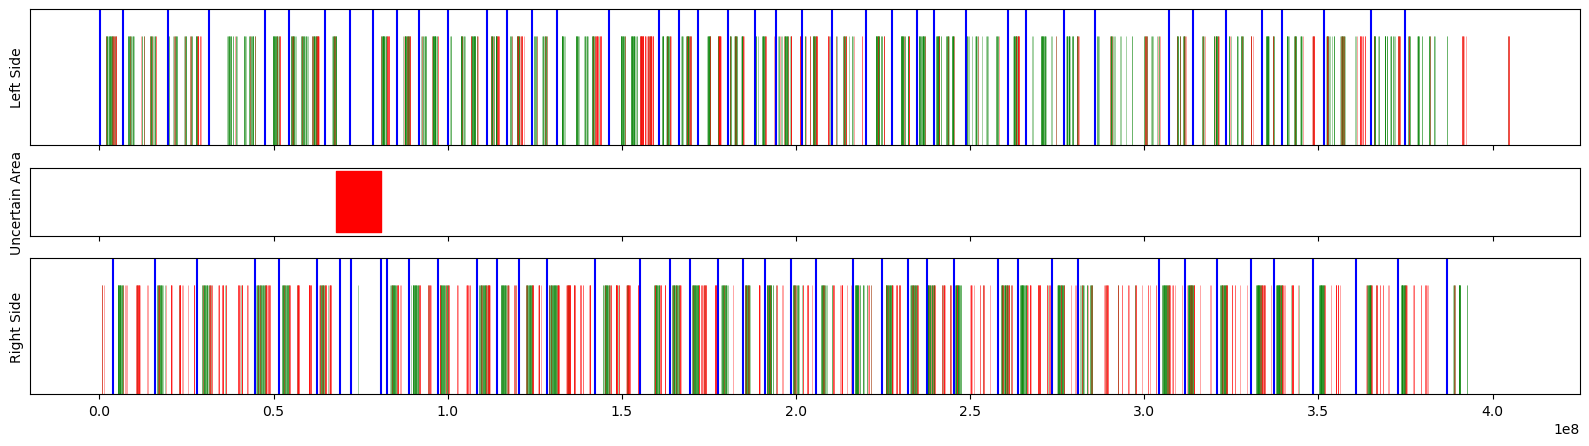

In [46]:
pkl_path='/home/zyyk78/HDD/zyyk78/Stage3/A04/20250326_00.pkl'
with open(pkl_path,"rb") as pkl_f:
    Event=pickle.load(pkl_f)
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax1_5, ax2) = plt.subplots(3, 1, figsize=(20, 5), 
                                   gridspec_kw={'height_ratios': [2 , 1 , 2]},sharex=True,)
sns.rugplot(Event['SlnL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['SlnR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['ROmL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ROmR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ModL']['Time_S'] , ax=ax1, height=1, linewidth=1.5, color='blue')
sns.rugplot(Event['ModR']['Time_S'] , ax=ax2, height=1, linewidth=1.5, color='blue')

if 'Blackhole' in Event:
    for i in range(len(Event['Blackhole']['Time_S'])):
        ax1_5.fill_betweenx(y=[-0.5, 0.5], x1 = Event['Blackhole']['Time_S'][i], x2=Event['Blackhole']['Time_E'][i],color='red')
ax1.set_yticks([])
ax1.set_ylabel('Left Side')
ax2.set_yticks([])
ax2.set_ylabel('Right Side')
ax1_5.set_yticks([])
ax1_5.set_ylabel('Uncertain Area')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


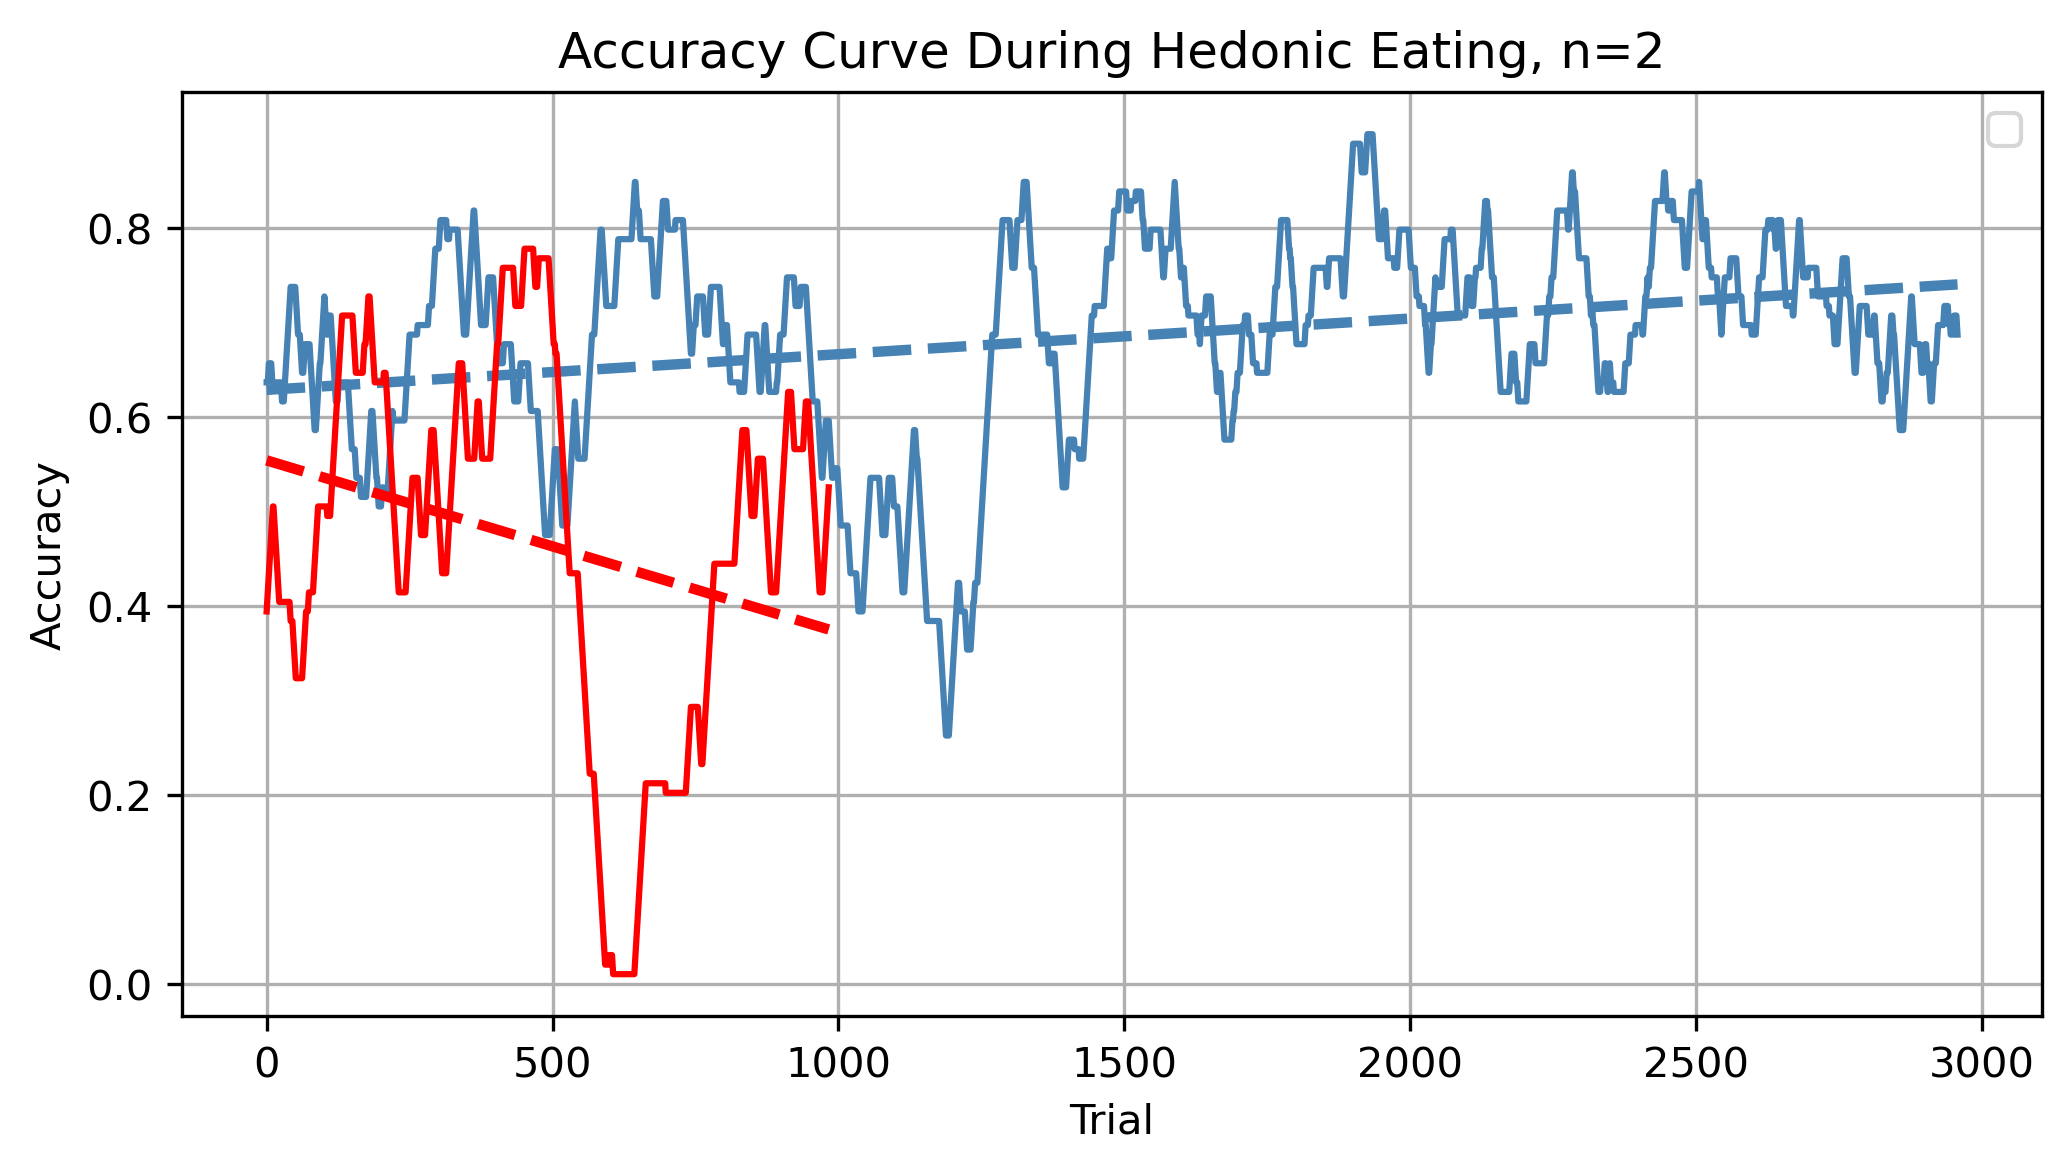

In [56]:
windows_size=100
plt.close('all')
plt.figure(figsize=(8,4),dpi=300)

def liner(x, a, b):
    return a * x + b
color_list=['steelblue','red','green','orange','purple']
count=0
for data_dict in data_collect:
    acc_collect = []
    data_list = data_dict['eve_list']
    for i in range(len(data_list)-windows_size):  
        _, _, acc = behave_ana.accuracy_rate(data_list, window=(i, i + windows_size-1))
        if acc != None:
            acc_collect.append(acc)
    x=[i for i in range(len(acc_collect))]
    params,_=curve_fit(liner,np.array(x),np.array(acc_collect))
    pred_y=liner(np.array(x),*params)
    plt.plot(pred_y, color=color_list[count],linestyle='--',linewidth=2.5)
    plt.plot(acc_collect, color=color_list[count])
    count+=1
plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve During Hedonic Eating, n=2')
plt.legend()
plt.grid(True)
plt.show()

Fitted parameters: [-5.28060391e-05  7.30728775e-01]


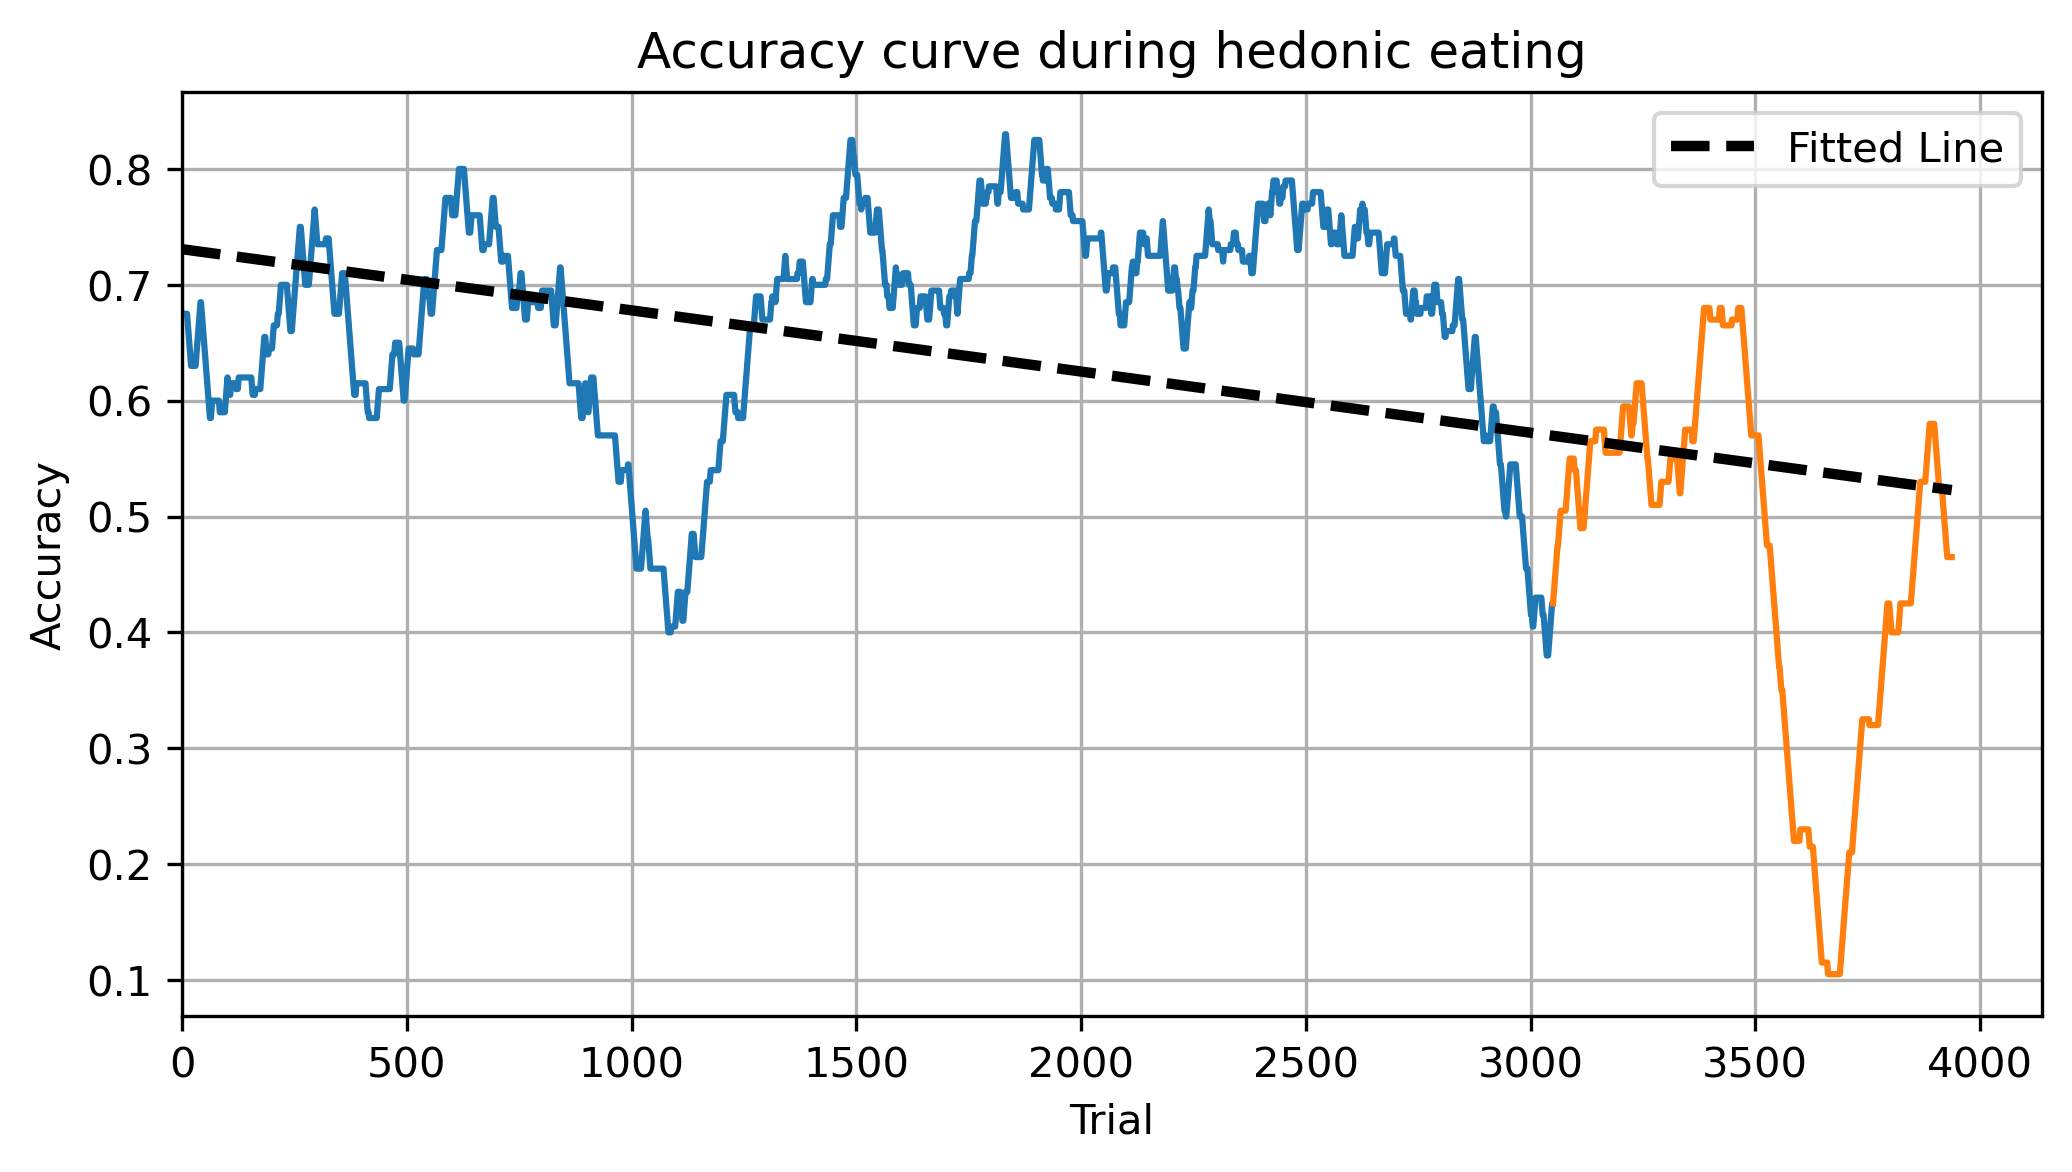

In [ ]:
plt.close('all')
plt.figure(figsize=(8,4),dpi=300)
windows_size=100
accum=0
tot_eve_list=[]
for data_dict in data_collect:
    tot_eve_list.extend( data_dict['eve_list'])


acc_collect = []
for i in range(len(behave_ana.transform_sequence(tot_eve_list)) - windows_size):
    _, _, acc = behave_ana.accuracy_rate(tot_eve_list, window=(i, i + windows_size))
    acc_collect.append(acc)
x_tot= np.array([i for i in range(len(acc_collect))])

def sigmoid(x, L, k, x0,y0):
    return L / (1 + np.exp(-k * (x - x0))) + y0
def liner(x, a, b):
    return a * x + b
params, covariance = curve_fit(liner, x_tot, acc_collect ,maxfev=10000)
print("Fitted parameters:", params)
count = 0
for data_dict in data_collect:
    count+=1
    eve_len = len(data_dict['eve_list'])
    y=acc_collect[max(0,accum-round(windows_size/2)):min(len(acc_collect),accum+eve_len-round(windows_size/2))]
    y_ave=data_dict['tot_acc']
    x = range(max(0,accum-round(windows_size/2)),min(len(acc_collect),accum+eve_len-round(windows_size/2)))  
    date=data_dict['date']
    plt.plot(x, y)
    accum+=eve_len
plt.plot(x_tot, liner(x_tot, *params),color='black', linestyle='--',linewidth=2.5, label='Fitted Line')
plt.xlim(0, len(acc_collect)+windows_size)
plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Accuracy curve during learning')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
idx_list=[]
sw_lat=[]
err_sw=[]

Text(0.5, 1.0, 'Switching Latency and Incorrect Switch\nDuring Hedonic Eating, n=2')

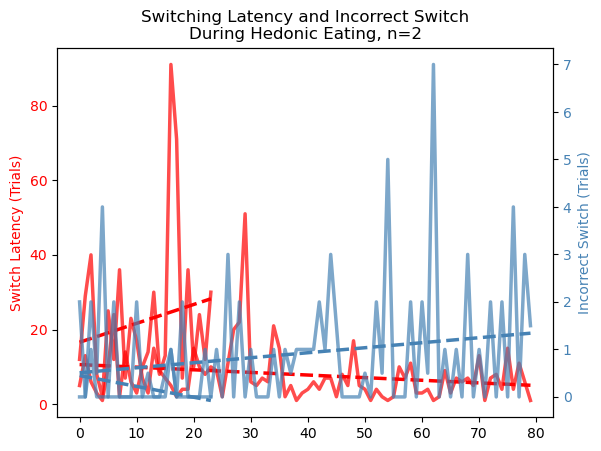

In [63]:
fig.clf()
fig, axL = plt.subplots()
axR = axL.twinx()
for data_dict in data_collect:
    lat_data=behave_ana.get_switching_latency(data_dict['eve_list'])
    sw_lat_l=[i[0] for i in lat_data]
    err_sw_l=[(len(i)-1)/2 for i in lat_data]
    x=[i for i in range(len(lat_data))]
    model1=LinearRegression()
    model1.fit(np.array(x).reshape(-1, 1), np.array(sw_lat_l).reshape(-1, 1))
    model2=LinearRegression()
    model2.fit(np.array(x).reshape(-1, 1), np.array(err_sw_l).reshape(-1, 1))
    y_lat=model1.predict(np.array(x).reshape(-1, 1))
    y_err=model2.predict(np.array(x).reshape(-1, 1))
    axL.plot(sw_lat_l,color='red',alpha=0.7,linewidth=2.5)
    axL.plot(y_lat, color='red', linestyle='--',linewidth=2.5)
    axR.plot(err_sw_l,color='steelblue',alpha=0.7,linewidth=2.5)
    axR.plot(y_err, color='steelblue', linestyle='--',linewidth=2.5)
    
axL.set_ylabel('Switch Latency (Trials)',color='red')
axL.tick_params(axis='y', labelcolor='red')
axR.set_ylabel('Incorrect Switch (Trials)',color='steelblue')
axR.tick_params(axis='y', labelcolor='steelblue')
axL.set_title('Switching Latency and Incorrect Switch\nDuring Hedonic Eating, n=2')


In [ ]:
# 计算每个session的switching latency和错误switch次数

fig_sw,ax_sw=plt.subplots()
fig_es,ax_es=plt.subplots()
for i in range(5):
    if len(matches) <i+1:
        break
    data_dict=data_collect[i]
    lat_data=behave_ana.get_switching_latency(data_dict['eve_list'])
    sw_lat.append(sum([i[0] for i in lat_data])/len(lat_data))
    err_sw.append(sum([(len(i)-1)/2 for i in lat_data])/len(lat_data))
    idx_list.append(i+1)

model1=LinearRegression()
model1.fit(np.array([i for i in idx_list if i != None]).reshape(-1,1),np.array([i for i in sw_lat if i != None]).reshape(-1,1))
model2=LinearRegression()
model2.fit(np.array([i for i in idx_list if i != None]).reshape(-1,1),np.array([i for i in err_sw if i != None]).reshape(-1,1))

x=[1,2,3,4,5]
y_lat=model1.predict(np.array(x).reshape(-1,1))
y_err=model2.predict(np.array(x).reshape(-1,1))

for i in range(round(len(idx_list)/5)):
    ax_sw.plot(idx_list[i*5:(i+1)*5],sw_lat[i*5:(i+1)*5],marker='o')
    ax_sw.set_title('Switching Latency, n=6')
    ax_sw.set_xlabel('Session')
    ax_sw.set_ylabel('Switching Latency (Trials)')
    
    ax_es.plot(idx_list[i*5:(i+1)*5],err_sw[i*5:(i+1)*5],marker='o')
    ax_es.set_title('Incorrect Switch, n=6')
    ax_es.set_xlabel('Session')
    ax_es.set_ylabel('Incorrect Switch (Times)')
    
ax_sw.plot(x,y_lat,color='black',linestyle='--',linewidth=2.5)
ax_sw.set_xticks(np.arange(1,6,1))
ax_es.plot(x,y_err,color='black',linestyle='--',linewidth=2.5)
ax_es.set_xticks(np.arange(1,6,1))

In [ ]:
fig_bys,ax_bys=plt.subplots(figsize=(8, 5),dpi=300)

In [ ]:
from scipy.stats import wilcoxon

lick_bias=np.array([1,
0.378190255,
0.246049661,
0.102040816,
0.059866962,
0.037037037,
0.008498584,
-0.087048832,
-0.865429234,
-0.946666667])

stat, p = wilcoxon(lick_bias)

plt.bar(range(len(lick_bias)), lick_bias)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel("Left-Bias-Right")
plt.title(f"Lick Bias during Pre-train, p={p:.2f}, n=6")
plt.show()

In [ ]:
# 贝叶斯自回归分析
import numpy as np
para_list=[]
bias_list=[]
acc_list=[]
for i in range(1000):
    sw_seq= []
    ns_seq= []
    for data_dict in data_collect:
        sw=behave_ana.get_switch_sequence(data_dict['eve_list'],10)
        sw_seq.extend(sw)
        ns_seq.extend(behave_ana.get_random_ns_sequence(data_dict['eve_list'],10,len(sw)))
    para,bias,acc=behave_ana.switch_bayes_reg(sw_seq,ns_seq)
    para_list.append(para)
    bias_list.append(bias)
    acc_list.append(acc)
para_list=np.array(para_list)
bias_list=np.array(bias_list)
acc_list=np.array(acc_list)

means = np.mean(para_list, axis=0)[0]
stds = np.std(para_list, axis=0)[0]
means_bias = np.mean(np.squeeze(bias_list))
stds_bias = np.std(np.squeeze(bias_list))
means_acc = np.mean(np.squeeze(acc_list))
stds_acc = np.std(np.squeeze(acc_list))

x = [i for i in range(-means.shape[0],0)]

# 绘制误差线折线图len_lat_data
ax_bys.errorbar(
    [i for i in range(-means.shape[0],0)],   
    y=means, 
    yerr=stds,
    fmt='-o',         # 线型：实线+圆圈标记
    capsize=5,        # 误差线端盖长度
    capthick=2,       # 端盖粗细
    elinewidth=1,     # 误差线粗细
    label='coef ± Std, Expert'
)

ax_bys.errorbar(
    0, 
    y=means_bias, 
    yerr=stds_bias,
    fmt='-o',         # 线型：实线+圆圈标记
    capsize=5,        # 误差线端盖长度
    capthick=2,       # 端盖粗细
    elinewidth=1,     # 误差线粗细
    label='bias ± Std, Expert'
)
ax_bys.axhline(y=0, color='red', linewidth=3, linestyle='-')
print(f'Pred_Acc={means_acc:.2f}±{stds_acc:.2f}')

ax_bys.set_ylabel('Coefficient')
ax_bys.set_xlabel('Trial')
ax_bys.set_title('Bayesian Autoregression Coefficient, Bootstrap=1000')
ax_bys.set_ylim(-3, 3)
legend=ax_bys.legend()
display(fig_bys)

In [ ]:
display(fig_bys)